# Energy Estimation Notebook
Pietro Pizzoccheri 10797420 [team leader]  
Lorenzo Bardelli 10831941 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### constants

In [3]:
#10797420 so 20 % 50 TODO check this
timeSleepSeconds = (20 % 50 + 5) / 10.0 
timeSleepMicroseconds = timeSleepSeconds * 1000000
print("Time to sleep:", timeSleepMicroseconds, "microseconds")

#10797420 so 7420 TODO check this
JBattery= 7420%5000+15000
print("Battery energy:", JBattery, "Joule")

Time to sleep: 2500000.0 microseconds
Battery energy: 17420 Joule


### Dataset analysis

In [6]:
df_sleep = pd.read_csv('data/deep_sleep.csv')
df_sender = pd.read_csv('data/sender.csv')
df_sensor = pd.read_csv('data/sensor-read.csv')

print(df_sleep.describe())
print(df_sender.describe())
print(df_sensor.describe())

              Data
count  1531.000000
mean    178.962064
std     197.935398
min      45.050000
25%      45.640000
50%      45.790000
75%     253.500000
max     636.760000
              Data
count  1394.000000
mean    607.412654
std       8.878444
min     599.530000
25%     605.380000
50%     605.960000
75%     606.580000
max     687.930000
              Data
count  1033.000000
mean    294.470242
std      56.413627
min     235.430000
25%     237.090000
50%     311.000000
75%     351.070000
max     352.220000


## Average cycle power consumption

Computing the average power consuption during each functional state by filtering the datapoints according to empirical observation of the plotted data.

| deep sleep | idle              | WiFi on  |
|------------|-------------------|----------|
| < 100 mW   | >200 mW, < 300 mW | > 400 mW | 

<Axes: title={'center': 'Power consumption (Deep Sleep)'}, xlabel='time [s]', ylabel='Power [mW]'>

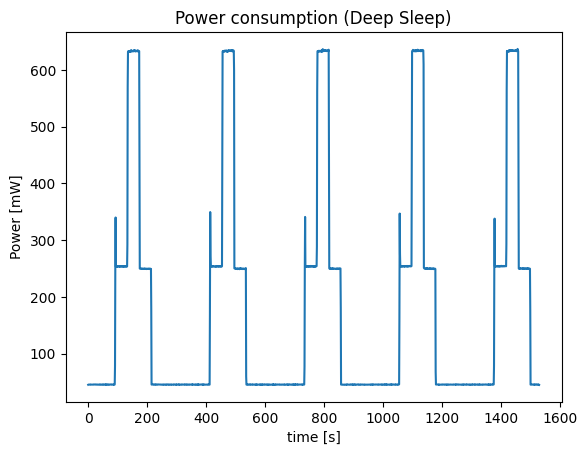

In [9]:
df_sleep.plot(
    xlabel="time [s]",
    ylabel="Power [mW]",
    title="Power consumption (Deep Sleep)",
    kind="line",
    legend=False,
)

In [8]:
deep_sleep_mean = round(df_sleep['Data'][df_sleep['Data'] < 100].mean(), 3)
idle_mean = round(df_sleep['Data'][df_sleep['Data'] > 200][df_sleep['Data'] < 300].mean(), 3)
tx_mean = round(df_sleep['Data'][df_sleep['Data'] > 400].mean(), 3)

print ("Deep Sleep Mean:", deep_sleep_mean, "mW")
print ("Idle Mean:", idle_mean, "mW")
print ("WiFi on Mean:", tx_mean, "mW")


Deep Sleep Mean: 45.777 mW
Idle Mean: 252.222 mW
WiFi on Mean: 627.259 mW


trasmission data from sender.csv, analysis on power consumption at 2dBm, 19.5dBm and idle

<Axes: title={'center': 'Power consumption (Sender)'}, xlabel='time [s]', ylabel='Power [mW]'>

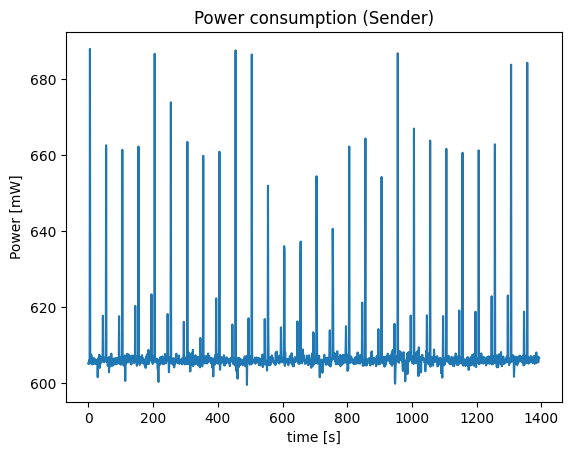

In [10]:
df_sender.plot(
    xlabel="time [s]",
    ylabel="Power [mW]",
    title="Power consumption (Sender)",
    kind="line",
    legend=False,
)

In [11]:
idle_wifi = round(df_sender['Data'][df_sender['Data'] < 610].mean(), 3)
tx2db_wifi = round(df_sender['Data'][df_sender['Data'] > 610][df_sender['Data'] < 630].mean(), 3)
tx19db_wifi = round(df_sender['Data'][df_sender['Data'] > 640].mean(), 3)
print ("Idle Mean:", idle_wifi, "mW")
print ("Tx 2dBm Mean:", tx2db_wifi, "mW")
print ("Tx 19.5dBm Mean:", tx19db_wifi, "mW")

Idle Mean: 605.889 mW
Tx 2dBm Mean: 617.883 mW
Tx 19.5dBm Mean: 667.411 mW


We assume that the data regarding the sensor consumption refers to the total energy consumed by all the sensors connected to the device, which in our case are the motion and luminosity sensors.

<Axes: title={'center': 'Power consumption (Sensor)'}, xlabel='time [s]', ylabel='Power [mW]'>

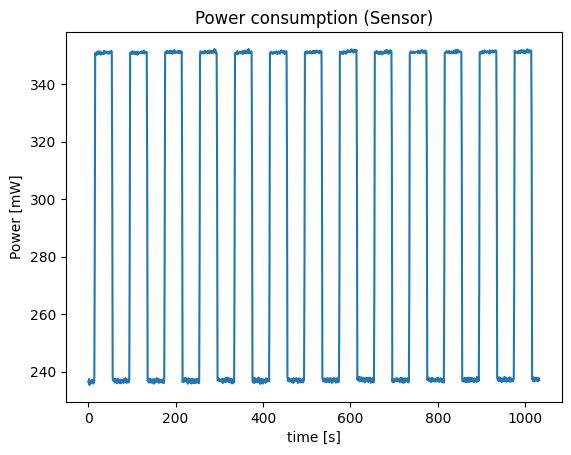

In [12]:
df_sensor.plot(
    xlabel="time [s]",
    ylabel="Power [mW]",
    title="Power consumption (Sensor)",
    kind="line",
    legend=False,
)

In [13]:
sensor_off_mean = round(df_sensor['Data'][df_sensor['Data'] < 300].mean(), 3)
sensor_on_mean = round(df_sensor['Data'][df_sensor['Data'] > 300].mean(), 3)
print ("Sensor off Mean:", sensor_off_mean, "mW")
print ("Sensor on Mean:", sensor_on_mean, "mW")

Sensor off Mean: 238.019 mW
Sensor on Mean: 350.162 mW


## Energy computation


In [14]:
states = [
    "Deep Sleep",
    "Idle",
    "Tx",
    "Sensor On",
    "Sensor Off",
    "WiFi idle",
    "WiFi Tx 2dBm",
    "WiFi Tx 19.5dBm",
]

power_avgs = [
    deep_sleep_mean,
    idle_mean,
    tx_mean,
    sensor_on_mean,
    sensor_off_mean,
    idle_wifi,
    tx2db_wifi,
    tx19db_wifi,
]

sorted_power_data = zip(states, power_avgs)
# print(sorted_power_data)
print("\nAverage Power Consumption for each state:")
for state, power in sorted_power_data:
    print(f"{state}: {power} mW")


Average Power Consumption for each state:
Deep Sleep: 45.777 mW
Idle: 252.222 mW
Tx: 627.259 mW
Sensor On: 350.162 mW
Sensor Off: 238.019 mW
WiFi idle: 605.889 mW
WiFi Tx 2dBm: 617.883 mW
WiFi Tx 19.5dBm: 667.411 mW


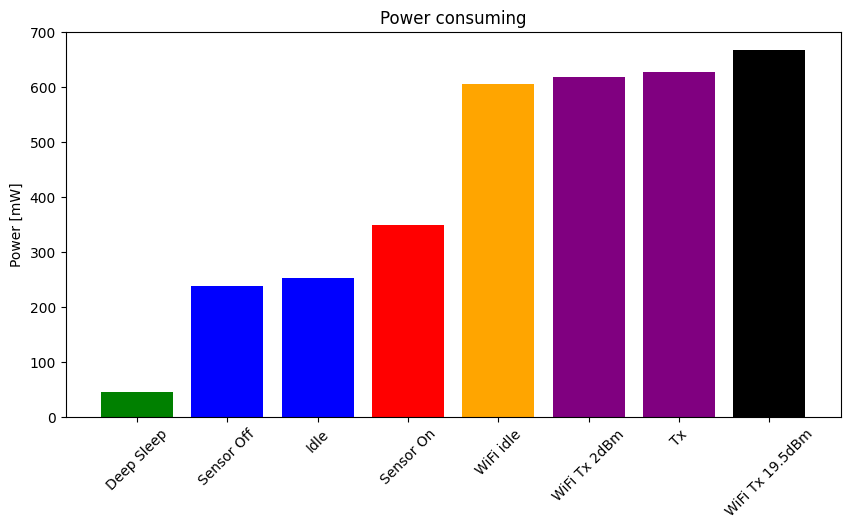

In [13]:
sorted_power_data = sorted(zip(power_avgs, states))
sorted_power_values, sorted_states = zip(*sorted_power_data)

plt.figure(figsize=(10, 5))
plt.bar(
    sorted_states,
    sorted_power_values,
    color=["green", "blue", "blue", "red", "orange", "purple", "purple", "black"],
)

plt.ylabel("Power [mW]")
plt.title("Power consuming")
plt.xticks(rotation=45)

plt.show()

In our case we don't consume Transmission power at 19.5 dBm, due the fact that we use the component only at 2dBm

## Time Estimation of our simulation

Dataset shape (working cycle of the esp): 
    Timestamp                   Status
0          0                  Booting
1        951          Setup completed
2       1769  Sensor reading complete
3     193049         Wifi initialized
4     193213             Message sent
5     247837          WiFi turned off
6     248095      Entering deep sleep


Average time for each operational state: 

idle time: 951.00 us
sensor reading time: 818.00 us
wifi init time: 191280.00 us
transmission [2 dBm] time: 164.00 us
wifi shutdown time: 54624.00 us
entering deep sleep time: 258.00 us


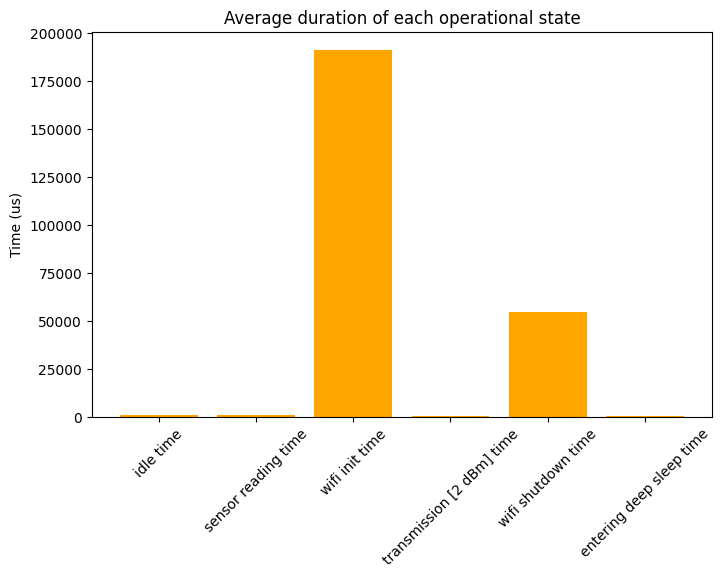

In [14]:
time_dataset = pd.read_csv("data/timings_from_simulation.csv")
print("Dataset shape (working cycle of the esp): \n", time_dataset.head(7))

time_dataset["Duration"] = time_dataset["Timestamp"].diff()
time_dataset.dropna(inplace=True)


# print(time_dataset)
diff_labels = [
    "idle time",
    "sensor reading time",
    "wifi init time",
    "transmission [2 dBm] time",
    "wifi shutdown time",
    "entering deep sleep time"
]

time_results = dict(zip(diff_labels, time_dataset["Duration"].values[:len(diff_labels)]))

print("\n\nAverage time for each operational state: \n")
for key, value in time_results.items():
    print(f"{key}: {value:.2f} us")

plt.figure(figsize=(8, 5))
plt.bar(time_results.keys(), time_results.values(), color='orange') # type: ignore
plt.ylabel("Time (us)")
plt.title("Average duration of each operational state")
plt.xticks(rotation=45)
plt.show()


## Energy consumption for each state

In [15]:
energy_idle = (idle_mean * time_results["idle time"]) / 1000000000 
energy_sensor_reading = (sensor_on_mean * time_results["sensor reading time"]) / 1000000000
energy_wifi_init = (idle_wifi * time_results["wifi init time"]) / 1000000000
energy_wifi_tx = (tx2db_wifi * time_results["transmission [2 dBm] time"]) / 1000000000
energy_wifi_shutdown = (idle_wifi * time_results["wifi shutdown time"]) / 1000000000
# timeSleepMicroseconds is the time spent in deep sleep
energy_deep_sleep = (deep_sleep_mean * timeSleepMicroseconds) / 1000000000 

print("\n\nEnergy consumption for each state: \n")
print(f"Idle: {energy_idle:.6f} J")
print(f"Sensor Reading: {energy_sensor_reading:.6f} J")
print(f"WiFi Init: {energy_wifi_init:.6f} J")
print(f"WiFi Tx: {energy_wifi_tx:.6f} J")
print(f"WiFi Shutdown: {energy_wifi_shutdown:.6f} J")
print(f"Deep Sleep: {energy_deep_sleep:.6f} J")

tot_energy_wifi = energy_idle + energy_sensor_reading + energy_wifi_init + energy_wifi_tx + energy_wifi_shutdown + energy_deep_sleep
tot_time_micorseconds = time_results["idle time"] + time_results["sensor reading time"] + time_results["wifi init time"] + time_results["transmission [2 dBm] time"] + time_results["wifi shutdown time"] + timeSleepMicroseconds
tot_time = tot_time_micorseconds / 1000000



Energy consumption for each state: 

Idle: 0.000240 J
Sensor Reading: 0.000286 J
WiFi Init: 0.115894 J
WiFi Tx: 0.000101 J
WiFi Shutdown: 0.033096 J
Deep Sleep: 0.114443 J


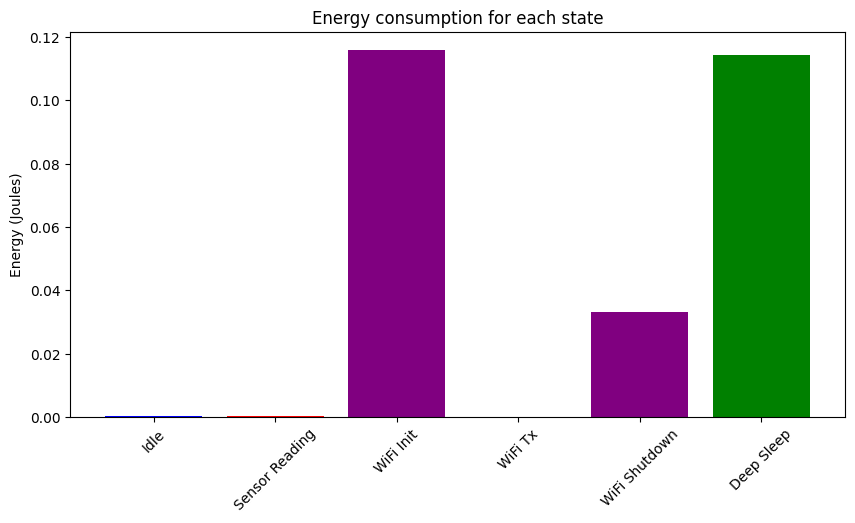

In [16]:
# plotting energy consumption
energy_states = [
    "Idle",
    "Sensor Reading",
    "WiFi Init",
    "WiFi Tx",
    "WiFi Shutdown",
    "Deep Sleep",
]

energy_values = [
    energy_idle,
    energy_sensor_reading,
    energy_wifi_init,
    energy_wifi_tx,
    energy_wifi_shutdown,
    energy_deep_sleep,
]

plt.figure(figsize=(10, 5))
plt.bar(
    energy_states,
    energy_values,
    color=["blue", "red", "purple", "black", "purple", "green"],
)
plt.ylabel("Energy (Joules)")
plt.title("Energy consumption for each state")
plt.xticks(rotation=45)
plt.show()

## Battery life computation

In [17]:
duty_cycles = JBattery/tot_energy_wifi
print(f"duty cycles: {duty_cycles:.0f}")

battery_life = duty_cycles*tot_time/3600
print(f"battery life: {battery_life:.2f} h")

duty cycles: 65970
battery life: 50.35 h


## Possible Improvements
A possible improvement is to use wi fi only when motion detected or light is above a certain treshold (luminosity threshold if sensor is outside, otherwise only motion detection maybe)

another possible improvement is to wake up every 4/5 seconds so we have longer sleeps (may impact UX but may save energy)

also another approach is to explore alternative techs since a couple of days of battery duration isnt really acceptable for the use case


If we use wi fi as specified above then we can have an extimation of the battery life given that we will turn on the wi fi for 20/25% of the battery lifetime considering an outdoor sensor (maybe more 40% for an indoor one without the luminosity threshold) since we may assume half the day with low light and the other half with good light, and that we will have motion detected for 50% of the time (which is a very high estimation but we want to be sure that we are not overestimating the battery life)

In [18]:
# battery life estimation not using any wi fi
tot_energy_no_wifi = energy_idle + energy_sensor_reading + energy_deep_sleep
duty_cycles_no_wifi = JBattery/tot_energy_no_wifi
tot_time_no_wifi_microseconds = time_results["idle time"] + time_results["sensor reading time"] + timeSleepMicroseconds
tot_time_no_wifi = tot_time_no_wifi_microseconds / 1000000
battery_life_no_wifi = duty_cycles_no_wifi*tot_time_no_wifi/3600
print(f"battery life without wifi: {battery_life_no_wifi:.2f} h")

battery life without wifi: 105.30 h


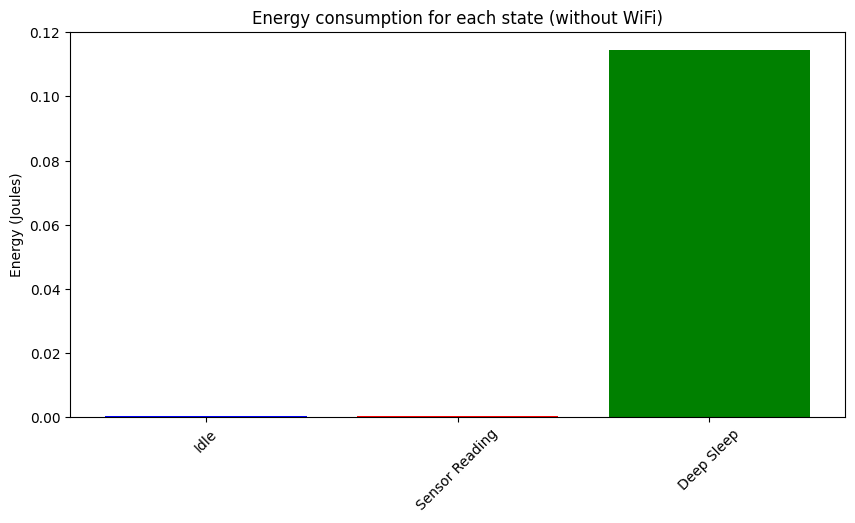

In [19]:
# graph of average energy consumption for each state not using wifi
energy_states_no_wifi = [
    "Idle",
    "Sensor Reading",
    "Deep Sleep",
]
energy_values_no_wifi = [
    energy_idle,
    energy_sensor_reading,
    energy_deep_sleep,
]
plt.figure(figsize=(10, 5))
plt.bar(
    energy_states_no_wifi,
    energy_values_no_wifi,
    color=["blue", "red", "green"],
)
plt.ylabel("Energy (Joules)")
plt.title("Energy consumption for each state (without WiFi)")
plt.xticks(rotation=45)
plt.show()

In [20]:
# weighted average of energy consumption considering 25% of the time we use wi fi and 75% we dont use it
tot_energy_mixed = 0.25 * tot_energy_wifi + 0.75 * tot_energy_no_wifi
duty_cycles_mixed = JBattery/tot_energy_mixed
tot_mixed_time_microseconds = 0.25 * tot_time_micorseconds + 0.75 * tot_time_no_wifi_microseconds
tot_time_mixed = tot_mixed_time_microseconds / 1000000
battery_life_mixed = duty_cycles_mixed*tot_time_mixed/3600
print(f"battery life with 25% wifi usage: {battery_life_mixed:.2f} h")

battery life with 25% wifi usage: 81.47 h


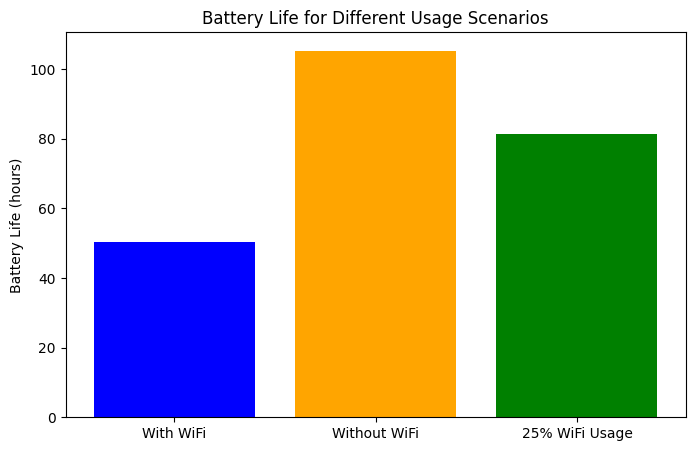

In [21]:
# graph comparing battery life for different usage scenarios
scenarios = ["With WiFi", "Without WiFi", "25% WiFi Usage"]
battery_lives = [battery_life, battery_life_no_wifi, battery_life_mixed]
plt.figure(figsize=(8, 5))
plt.bar(scenarios, battery_lives, color=["blue", "orange", "green"])
plt.ylabel("Battery Life (hours)")
plt.title("Battery Life for Different Usage Scenarios")
plt.show()

In [22]:
# percentage of battery life gain
battery_life_gain = ((battery_life_mixed - battery_life) / battery_life) * 100
print(f"battery life gain with 25% wifi usage: {battery_life_gain:.2f} %")
# hours gained
hours_gained = battery_life_mixed - battery_life
print(f"hours gained with 25% wifi usage: {hours_gained:.2f} h")

battery life gain with 25% wifi usage: 61.80 %
hours gained with 25% wifi usage: 31.12 h


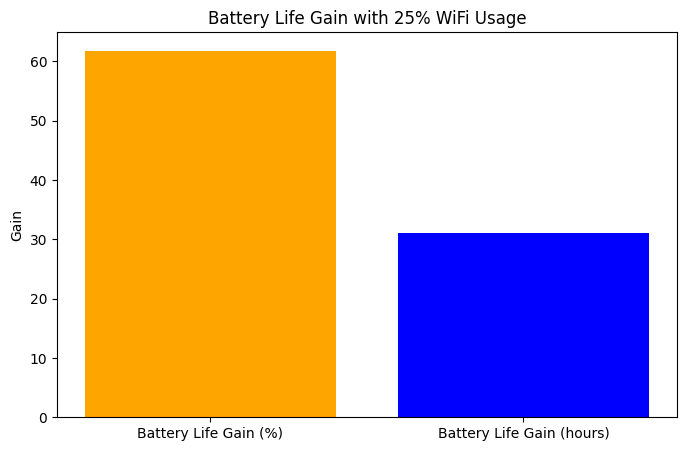

In [23]:
# graph of percentual and hourly gain in battery life with 25% wifi usage compared to 100% wifi usage
labels = ["Battery Life Gain (%)", "Battery Life Gain (hours)"]
values = [battery_life_gain, hours_gained]
plt.figure(figsize=(8, 5))
plt.bar(labels, values, color=["orange", "blue"])
plt.ylabel("Gain")
plt.title("Battery Life Gain with 25% WiFi Usage")
plt.show()